
# Physics-Aware VAE on fastMRI Prostate DICOMS + Labels

This notebook replaces the earlier synthetic, k-space-only demo with a **real-data implementation** built on the local fastMRI Prostate assets we actually have:
- reconstructed image data in `kaggle project/DICOMS`,
- official PI-RADS label CSVs in `kaggle project/labels`.

## What this notebook does now
- builds a clean, label-aware slice dataset from local DICOM bundles,
- explains the label hierarchy clearly,
- performs dataset EDA before any modelling,
- trains a **physics-aware VAE classifier** on real multiparametric image slices,
- uses `T2 + ADC + B1500` as a practical image-domain input bundle.

## What this notebook does not claim
- this is **not** true raw-k-space reconstruction modelling,
- this is **not** the original PIA protocol with 16 diffusion-relaxation signals per voxel,
- this is **not** pathology-confirmed cancer classification.

Instead, this notebook is a practical bridge: it lets us implement a **PIVA-style / physics-aware latent model** on the fastMRI prostate image-and-label dataset we already possess.


In [1]:
from __future__ import annotations

import importlib.util
import math
import random
import sys
import warnings
from functools import lru_cache
from pathlib import Path

# Keep the dependency gate simple so the notebook fails early with a clear message.
REQUIRED_MODULES = {
    "pydicom": "pydicom",
    "sklearn": "scikit-learn",
}
missing_modules = [pkg for mod, pkg in REQUIRED_MODULES.items() if importlib.util.find_spec(mod) is None]
if missing_modules:
    raise ModuleNotFoundError(
        "Missing notebook dependencies: " + ", ".join(missing_modules) + ". Install them with: "
        + f"{sys.executable} -m pip install " + " ".join(missing_modules)
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from pydicom.uid import UID
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


def compression_plugin_status() -> dict[str, bool]:
    # These optional packages let pydicom decode JPEG-compressed pixel data.
    return {
        'gdcm': importlib.util.find_spec('gdcm') is not None,
        'pylibjpeg': importlib.util.find_spec('pylibjpeg') is not None,
        'pylibjpeg_libjpeg': importlib.util.find_spec('pylibjpeg_libjpeg') is not None,
    }


def compressed_dicom_requires_plugins(dicoms_root: Path) -> tuple[bool, str | None, str | None]:
    # Scan a few files up front so the notebook can fail early with a useful install command.
    for file_path in sorted(dicoms_root.rglob('*')):
        if not file_path.is_file() or file_path.name.startswith('.'):
            continue
        try:
            ds = pydicom.dcmread(str(file_path), stop_before_pixels=True, force=True)
            ts = getattr(getattr(ds, 'file_meta', None), 'TransferSyntaxUID', None)
            if ts is None:
                continue
            ts_uid = UID(str(ts))
            return bool(ts_uid.is_compressed), str(ts_uid), ts_uid.name
        except Exception:
            continue
    return False, None, None


def find_myworks_root(start: Path | None = None) -> Path:
    # Resolve the notebook relative to the shared repo layout so the notebook stays portable.
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "DICOMS").exists() and (candidate / "labels").exists():
            return candidate.parent
        if (candidate / "NYU" / "DICOMS").exists():
            return candidate
        nested_nyu = candidate / "capstone_MSADS" / "myworks" / "NYU" / "DICOMS"
        if nested_nyu.exists():
            return candidate / "capstone_MSADS" / "myworks"
        legacy_direct = candidate / "kaggle project" / "DICOMS"
        legacy_nested = candidate / "capstone_MSADS" / "repo" / "myworks" / "kaggle project" / "DICOMS"
        if legacy_direct.exists():
            return candidate
        if legacy_nested.exists():
            return candidate / "capstone_MSADS" / "repo" / "myworks"
    raise FileNotFoundError("Could not locate `NYU/DICOMS` under myworks.")


MYWORKS_ROOT = find_myworks_root()
REPO_ROOT = MYWORKS_ROOT.parent
NYU_ROOT = MYWORKS_ROOT / "NYU"
DICOMS_ROOT = NYU_ROOT / "DICOMS"
LABEL_ROOT = NYU_ROOT / "labels"
OUTPUT_ROOT = MYWORKS_ROOT / "artifacts" / "fastmri_piva"
PROJECT_ROOT = MYWORKS_ROOT / "prostate_pirads_gradio"
PROJECT_MODEL_PATH = PROJECT_ROOT / "model" / "prostate_pirads_vae.pt"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PROJECT_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if str(NYU_ROOT) not in sys.path:
    sys.path.insert(0, str(NYU_ROOT))

from prostate_pirads_model import (
    PIRADS_CLASS_NAMES,
    PhysicsAwareSliceVAE,
    build_checkpoint_payload,
    physics_aware_vae_loss,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compressed_sample_found, sample_ts_uid, sample_ts_name = compressed_dicom_requires_plugins(DICOMS_ROOT)
plugin_status = compression_plugin_status()
has_decoder = plugin_status['gdcm'] or (plugin_status['pylibjpeg'] and plugin_status['pylibjpeg_libjpeg'])
if compressed_sample_found and not has_decoder:
    raise ModuleNotFoundError(
        'This dataset uses compressed DICOM pixel data '
        + f'({sample_ts_name} / {sample_ts_uid}), but no compatible decoder plugin is installed. '
        + 'Install one of these before running the notebook: '\
        + f"{sys.executable} -m pip install pylibjpeg pylibjpeg-libjpeg "
        + 'or '\
        + f"{sys.executable} -m pip install gdcm"
    )

print(f"Myworks root : {MYWORKS_ROOT}")
print(f"NYU root     : {NYU_ROOT}")
print(f"DICOMS root  : {DICOMS_ROOT}")
print(f"Labels root  : {LABEL_ROOT}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Model path   : {PROJECT_MODEL_PATH}")
print(f"Output root  : {OUTPUT_ROOT}")
print(f"Device       : {DEVICE}")
print(f"Decoder plug.: {plugin_status}")
if compressed_sample_found:
    print(f"Sample syntax: {sample_ts_name} ({sample_ts_uid})")


Myworks root : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/repo/myworks
DICOMS root  : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/repo/myworks/kaggle project/DICOMS
Labels root  : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/repo/myworks/kaggle project/labels
Output root  : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/repo/myworks/artifacts/fastmri_piva
Device       : cpu
Decoder plug.: {'gdcm': False, 'pylibjpeg': True, 'pylibjpeg_libjpeg': False}



## 1. What The Data Means

We have two separate but aligned components:

### A. `DICOMS/`
This is the reconstructed image archive.
For most patients, the folder contains four image sequences:
- `AX_T2`: anatomical T2-weighted prostate MRI,
- `AX_DIFFUSION_ADC`: ADC maps,
- `AX_DIFFUSION_CALC_BVAL`: calculated high-b diffusion images (B1500),
- `AX_DIFFUSION_TRACEW`: trace-weighted diffusion images.

### B. `labels/`
These are the official fastMRI Prostate label CSVs:
- `t2_slice_level_labels.csv`: PI-RADS score for each T2 slice,
- `dwi_slice_level_labels.csv`: PI-RADS score for each diffusion slice,
- `volume_exam_labels.csv`: patient-level labels summarising sequence and exam severity.

### C. What target we will model
For a practical binary task, this notebook uses:
- `joint_pirads = max(T2_slice_PIRADS, DWI_slice_PIRADS)`
- `target_binary = 1 if joint_pirads > 2 else 0`

This matches the common fastMRI prostate research convention of treating **PI-RADS > 2** as a proxy for clinically significant cancer risk.


### Annotation: Dataset Build Logic

This block creates the main modelling table. It scans the DICOM folders, loads the official T2 and DWI slice labels, converts fastMRI patient IDs into the same zero-padded patient IDs used by the local folders, and merges both modalities on `patient_id + slice`.

The result is `matched_slice_table`, which is the master dataframe used by the rest of the notebook. `joint_pirads` is the higher of the T2 and DWI slice scores, and `usable_triplet` marks rows where the same slice index exists in all three model inputs: `T2`, `ADC`, and `B1500`.


In [2]:
EXPECTED_SEQUENCES = [
    'AX_T2',
    'AX_DIFFUSION_ADC',
    'AX_DIFFUSION_CALC_BVAL',
    'AX_DIFFUSION_TRACEW',
]


def list_visible_files(series_dir: Path) -> list[Path]:
    # Ignore hidden files like .DS_Store so slice counts stay honest.
    return sorted([p for p in series_dir.iterdir() if p.is_file() and not p.name.startswith('.')], key=lambda p: p.name)


def clean_label_df(df: pd.DataFrame) -> pd.DataFrame:
    # The exported CSVs carry an index-like unnamed column that is not part of the real labels.
    unnamed_cols = [c for c in df.columns if str(c).startswith('Unnamed:')]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    return df.copy()


def build_series_index(dicoms_root: Path) -> pd.DataFrame:
    # Build a compact inventory of what image sequences exist per patient on disk.
    rows = []
    for patient_dir in sorted([p for p in dicoms_root.iterdir() if p.is_dir()], key=lambda p: p.name):
        for seq_dir in sorted([d for d in patient_dir.iterdir() if d.is_dir()], key=lambda d: d.name):
            files = list_visible_files(seq_dir)
            rows.append({
                'patient_id': patient_dir.name,
                'sequence_name': seq_dir.name,
                'series_dir': str(seq_dir),
                'file_count': len(files),
            })
    return pd.DataFrame(rows).sort_values(['patient_id', 'sequence_name']).reset_index(drop=True)


series_index = build_series_index(DICOMS_ROOT)
t2_slice_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 't2_slice_level_labels.csv'))
dwi_slice_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 'dwi_slice_level_labels.csv'))
volume_exam_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 'volume_exam_labels.csv'))

for df in [t2_slice_labels, dwi_slice_labels, volume_exam_labels]:
    # Convert the numeric fastMRI IDs into zero-padded patient IDs that match the folder names in DICOMS.
    df['fastmri_pt_id'] = df['fastmri_pt_id'].astype(int)
    df['patient_id'] = df['fastmri_pt_id'].map(lambda x: f'{x:03d}')

# Join T2 and DWI slice labels on patient + slice so each usable row has one matched label pair.
slice_pairs = t2_slice_labels[['patient_id', 'slice', 'PIRADS', 'data_split']].rename(columns={'PIRADS': 't2_pirads', 'data_split': 'data_split_t2'}).merge(
    dwi_slice_labels[['patient_id', 'slice', 'PIRADS', 'data_split']].rename(columns={'PIRADS': 'dwi_pirads', 'data_split': 'data_split_dwi'}),
    on=['patient_id', 'slice'],
    how='inner'
)
# Use the higher of the two modality-specific PI-RADS scores as a five-class slice-level target.
slice_pairs['joint_pirads'] = slice_pairs[['t2_pirads', 'dwi_pirads']].max(axis=1)
slice_pairs['target_pirads'] = slice_pairs['joint_pirads'].astype(int)
slice_pairs['target_class'] = (slice_pairs['target_pirads'] - 1).astype(int)
# Keep the binary flag for class-balance summaries and clinical-significance threshold checks.
slice_pairs['target_binary'] = (slice_pairs['target_pirads'] > 2).astype(int)
slice_pairs['data_split'] = slice_pairs['data_split_t2']

sequence_counts = series_index.pivot_table(index='patient_id', columns='sequence_name', values='file_count', aggfunc='first')
for seq in EXPECTED_SEQUENCES:
    if seq not in sequence_counts.columns:
        sequence_counts[seq] = np.nan
sequence_counts = sequence_counts[EXPECTED_SEQUENCES].reset_index()

# Attach patient-level sequence counts and volume/exam labels to every matched slice row.
patient_table = sequence_counts.merge(volume_exam_labels[['patient_id', 't2_volume_level', 'dwi_volume_level', 'exam_level']], on='patient_id', how='left')
matched_slice_table = slice_pairs.merge(patient_table, on='patient_id', how='left')
matched_slice_table['slice_zero_based'] = matched_slice_table['slice'] - 1
# Keep only slices that exist in all three channels the model consumes: T2, ADC, and calculated B1500.
matched_slice_table['usable_triplet'] = (
    (matched_slice_table['slice'] <= matched_slice_table['AX_T2'])
    & (matched_slice_table['slice'] <= matched_slice_table['AX_DIFFUSION_ADC'])
    & (matched_slice_table['slice'] <= matched_slice_table['AX_DIFFUSION_CALC_BVAL'])
).astype(int)
matched_slice_table = matched_slice_table.loc[matched_slice_table['usable_triplet'] == 1].copy()

summary = pd.DataFrame({
    'metric': [
        'patients_in_DICOMS',
        'patients_with_volume_labels',
        'matched_slice_rows',
        'usable_triplet_rows',
        'binary_positive_slices',
        'binary_positive_patients_exam_gt_2',
    ],
    'value': [
        series_index['patient_id'].nunique(),
        volume_exam_labels['patient_id'].nunique(),
        len(slice_pairs),
        len(matched_slice_table),
        int(matched_slice_table['target_binary'].sum()),
        int((volume_exam_labels['exam_level'] > 2).sum()),
    ]
})

display(summary)
display(matched_slice_table.head())


,metric,value
0,patients_in_DICOMS,312
1,patients_with_volume_labels,312
2,matched_slice_rows,9483
3,usable_triplet_rows,9483
4,binary_positive_slices,666
5,binary_positive_patients_exam_gt_2,151


,patient_id,slice,t2_pirads,data_split_t2,dwi_pirads,data_split_dwi,joint_pirads,target_binary,data_split,AX_T2,AX_DIFFUSION_ADC,AX_DIFFUSION_CALC_BVAL,AX_DIFFUSION_TRACEW,t2_volume_level,dwi_volume_level,exam_level,slice_zero_based,usable_triplet
0,001,1,1,training,1,training,1,0,training,30.0,30.0,30.0,60.0,1,1,1,0,1
1,001,2,1,training,1,training,1,0,training,30.0,30.0,30.0,60.0,1,1,1,1,1
2,001,3,1,training,1,training,1,0,training,30.0,30.0,30.0,60.0,1,1,1,2,1
3,001,4,1,training,1,training,1,0,training,30.0,30.0,30.0,60.0,1,1,1,3,1
4,001,5,1,training,1,training,1,0,training,30.0,30.0,30.0,60.0,1,1,1,4,1


/var/folders/v_/pv32b_4x16b55v2rdc_2dqww0000gn/T/ipykernel_46929/4050208120.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([counts_df[c] for c in counts_df.columns], labels=counts_df.columns)


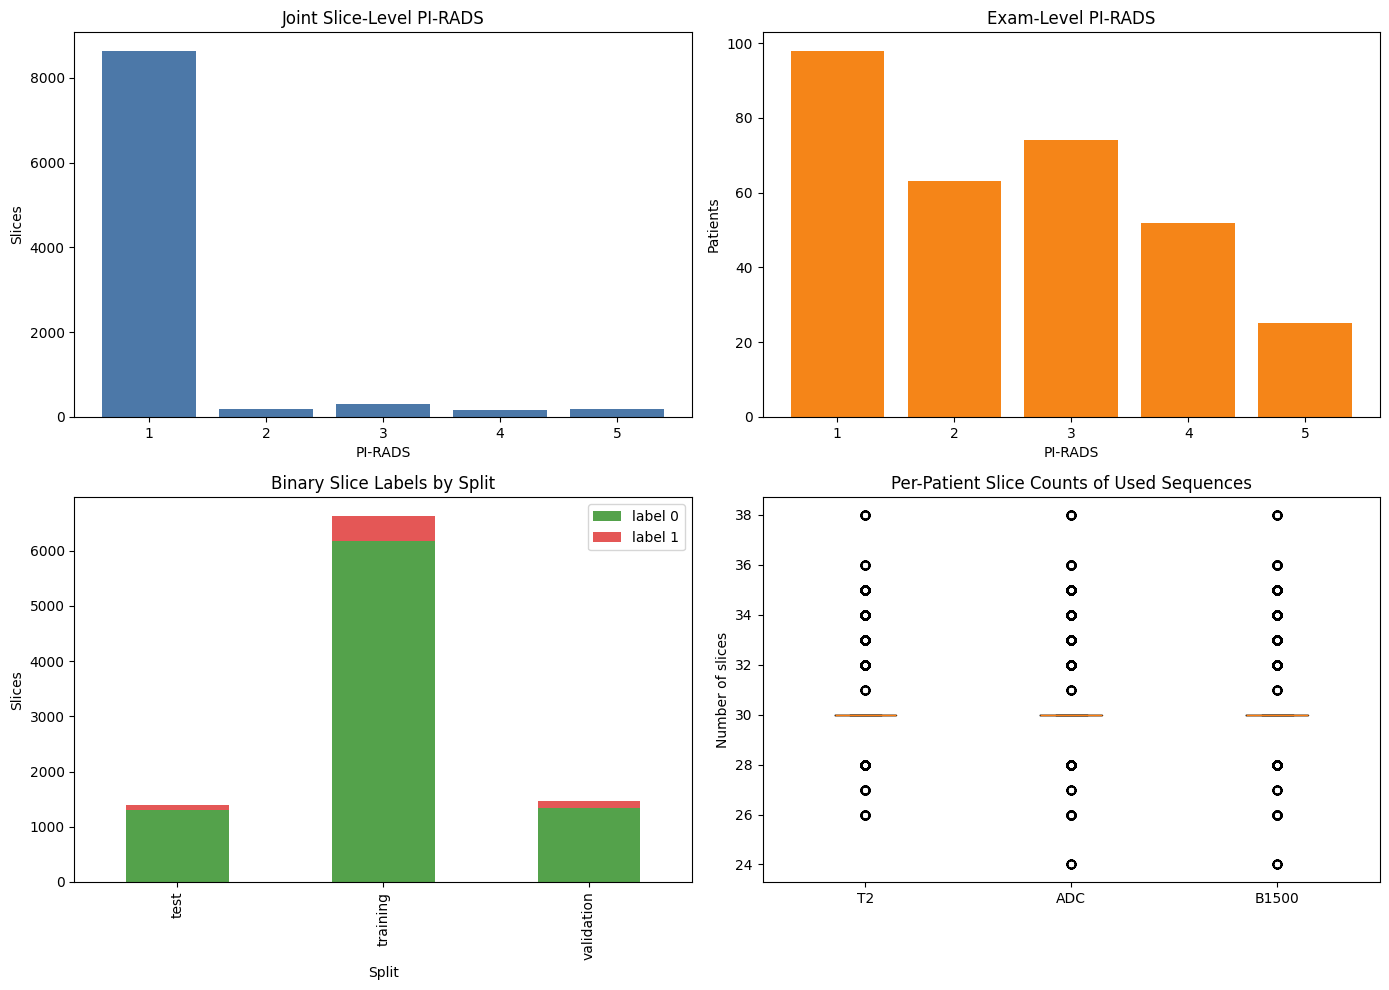

What is what:
- T2 slice labels and DWI slice labels are joined on patient and slice index.
- joint_pirads = max(T2 PIRADS, DWI PIRADS).
- target_binary = 1 if joint_pirads > 2 else 0.
- exam_level stays available as a patient-level label for later analysis.


In [3]:
# These quick plots explain the class balance and the structural coverage before modelling.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

joint_counts = matched_slice_table['joint_pirads'].value_counts().sort_index()
axes[0, 0].bar(joint_counts.index.astype(str), joint_counts.values, color='#4C78A8')
axes[0, 0].set_title('Joint Slice-Level PI-RADS')
axes[0, 0].set_xlabel('PI-RADS')
axes[0, 0].set_ylabel('Slices')

exam_counts = volume_exam_labels['exam_level'].value_counts().sort_index()
axes[0, 1].bar(exam_counts.index.astype(str), exam_counts.values, color='#F58518')
axes[0, 1].set_title('Exam-Level PI-RADS')
axes[0, 1].set_xlabel('PI-RADS')
axes[0, 1].set_ylabel('Patients')

split_counts = matched_slice_table.groupby(['data_split', 'target_binary']).size().unstack(fill_value=0)
split_counts.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#54A24B', '#E45756'])
axes[1, 0].set_title('Binary Slice Labels by Split')
axes[1, 0].set_xlabel('Split')
axes[1, 0].set_ylabel('Slices')
axes[1, 0].legend(['label 0', 'label 1'])

counts_df = matched_slice_table[['AX_T2', 'AX_DIFFUSION_ADC', 'AX_DIFFUSION_CALC_BVAL']].rename(columns={
    'AX_T2': 'T2',
    'AX_DIFFUSION_ADC': 'ADC',
    'AX_DIFFUSION_CALC_BVAL': 'B1500',
})
axes[1, 1].boxplot([counts_df[c] for c in counts_df.columns], labels=counts_df.columns)
axes[1, 1].set_title('Per-Patient Slice Counts of Used Sequences')
axes[1, 1].set_ylabel('Number of slices')

plt.tight_layout()
plt.show()

print('What is what:')
print('- T2 slice labels and DWI slice labels are joined on patient and slice index.')
print('- joint_pirads = max(T2 PIRADS, DWI PIRADS).')
print('- target_binary = 1 if joint_pirads > 2 else 0.')
print('- exam_level stays available as a patient-level label for later analysis.')


### Annotation: Image Loading And Preprocessing

This section turns raw DICOM files into model-ready arrays. Each slice is read, rescaled using DICOM metadata when needed, center-cropped to reduce background, percentile-normalized so intensities are comparable across patients, and resized to a fixed spatial size.

`build_triplet(...)` is the key helper: it returns a 3-channel stack ordered as `T2`, `ADC`, `B1500` for one patient and one slice index.


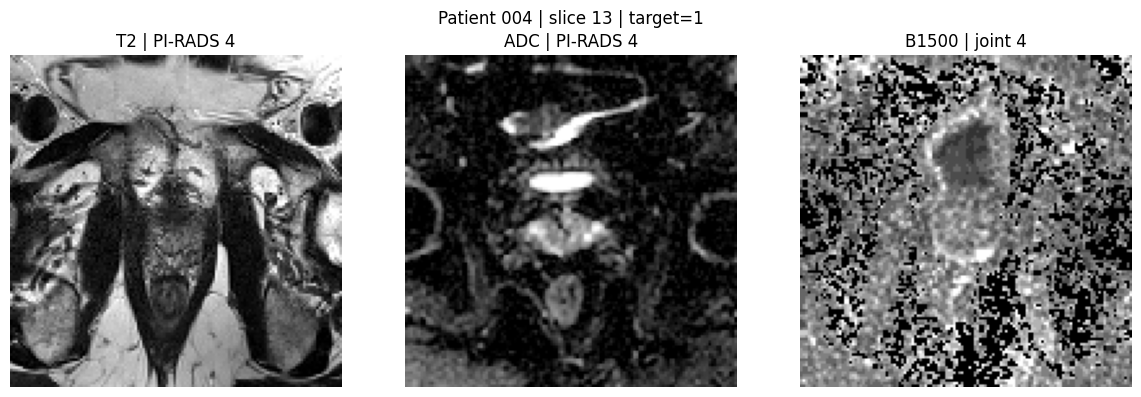

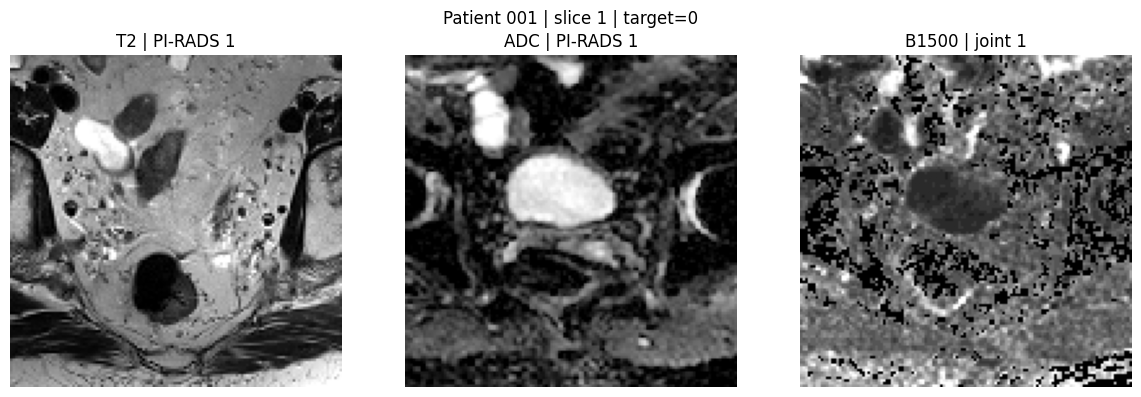

In [4]:
@lru_cache(maxsize=4096)
def get_series_files(patient_id: str, sequence_name: str) -> tuple[Path, ...]:
    # Cache file discovery because the same patient/sequence is reused across many slices.
    series_dir = DICOMS_ROOT / patient_id / sequence_name
    files = tuple(list_visible_files(series_dir))
    if not files:
        raise FileNotFoundError(f'No files found for {patient_id}/{sequence_name}')
    return files


@lru_cache(maxsize=8192)
def read_dicom(file_path: str):
    # Cache DICOM reads to reduce repeated I/O during training and visualization.
    return pydicom.dcmread(file_path, force=True)


def load_slice(patient_id: str, sequence_name: str, slice_zero_based: int) -> np.ndarray:
    # Read one image slice and apply DICOM rescale terms if present.
    files = get_series_files(patient_id, sequence_name)
    if slice_zero_based < 0 or slice_zero_based >= len(files):
        raise IndexError(f'Slice {slice_zero_based} out of bounds for {patient_id}/{sequence_name}')
    file_path = files[slice_zero_based]
    ds = read_dicom(str(file_path))
    try:
        image = ds.pixel_array.astype(np.float32)
    except RuntimeError as exc:
        ts = getattr(getattr(ds, 'file_meta', None), 'TransferSyntaxUID', 'unknown')
        raise RuntimeError(
            f'Unable to decode pixel data for {file_path} with transfer syntax {ts}. '
            + 'Install a DICOM decoder plugin such as '\
            + f"{sys.executable} -m pip install pylibjpeg pylibjpeg-libjpeg "
            + 'or '\
            + f"{sys.executable} -m pip install gdcm"
        ) from exc
    slope = float(getattr(ds, 'RescaleSlope', 1.0) or 1.0)
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0) or 0.0)
    return image * slope + intercept


def normalize_image(image: np.ndarray, q_low: float = 1.0, q_high: float = 99.0) -> np.ndarray:
    # Percentile clipping gives a stable display/training range without being too sensitive to outliers.
    lo, hi = np.percentile(image, [q_low, q_high])
    if hi <= lo:
        lo, hi = float(image.min()), float(image.max())
    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo)).astype(np.float32)


def center_crop(image: np.ndarray, fraction: float = 0.88) -> np.ndarray:
    # Prostate occupies the central field of view, so a center crop reduces empty background.
    h, w = image.shape[:2]
    new_h = max(1, int(h * fraction))
    new_w = max(1, int(w * fraction))
    top = (h - new_h) // 2
    left = (w - new_w) // 2
    return image[top:top + new_h, left:left + new_w]


def resize_nn(image: np.ndarray, size: tuple[int, int] = (128, 128)) -> np.ndarray:
    # Keep resizing lightweight and dependency-free for notebook portability.
    target_h, target_w = size
    y_idx = np.linspace(0, image.shape[0] - 1, target_h).astype(int)
    x_idx = np.linspace(0, image.shape[1] - 1, target_w).astype(int)
    return image[np.ix_(y_idx, x_idx)].astype(np.float32)


def build_triplet(patient_id: str, slice_zero_based: int, size: tuple[int, int] = (128, 128)) -> np.ndarray:
    # Build the 3-channel image stack that the VAE sees for one matched slice.
    channels = []
    for seq in ['AX_T2', 'AX_DIFFUSION_ADC', 'AX_DIFFUSION_CALC_BVAL']:
        image = load_slice(patient_id, seq, slice_zero_based)
        image = normalize_image(center_crop(image))
        image = resize_nn(image, size=size)
        channels.append(image)
    return np.stack(channels, axis=0).astype(np.float32)


def show_triplet(row: pd.Series):
    # Visual sanity check: matched channels plus their labels for one slice.
    triplet = build_triplet(row['patient_id'], int(row['slice_zero_based']))
    titles = [
        f"T2 | PI-RADS {row['t2_pirads']}",
        f"ADC | PI-RADS {row['dwi_pirads']}",
        f"B1500 | joint {row['joint_pirads']}",
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i in range(3):
        axes[i].imshow(triplet[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')
    fig.suptitle(f"Patient {row['patient_id']} | slice {int(row['slice'])} | target={int(row['target_binary'])}")
    plt.tight_layout()
    plt.show()

sample_pos = matched_slice_table.loc[matched_slice_table['target_binary'] == 1].iloc[0]
sample_neg = matched_slice_table.loc[matched_slice_table['target_binary'] == 0].iloc[0]
show_triplet(sample_pos)
show_triplet(sample_neg)



## 2. Real Slice Dataset for PIVA-Style Modelling

Each training example in this notebook is a **matched slice triplet**:
- channel 1: `AX_T2`
- channel 2: `AX_DIFFUSION_ADC`
- channel 3: `AX_DIFFUSION_CALC_BVAL`

This is a practical image-domain substitute for the richer raw signal setting.

The model is "physics-aware" in a limited but useful sense:
- it respects that diffusion-related channels should share structure,
- it reconstructs all channels jointly,
- it learns a latent representation that is regularized both for reconstruction and cancer-risk classification.


### Annotation: VAE Dataset, Architecture, And Loss

The dataset wrapper returns one matched slice triplet plus its binary target. The model is a compact convolutional VAE with a classifier head attached to the latent code, so the latent space is trained to be useful for both reconstruction and risk prediction.

The loss has four parts: reconstruction loss, KL regularization, binary classification loss, and a small consistency term that encourages the reconstructed diffusion-derived channels to stay reasonably aligned.


In [5]:
class FastMRIProstateSliceDataset(Dataset):
    # Each item is one matched T2/ADC/B1500 slice triplet plus a five-class PI-RADS label.
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        x = build_triplet(row['patient_id'], int(row['slice_zero_based']))
        y = np.int64(row['target_class'])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

print('Five-class PI-RADS dataset, model, and loss are ready.')


Model and loss are ready.


### Annotation: Patient-Level Split Strategy

The train, validation, and test splits are created at the patient level rather than the slice level. That prevents the model from seeing very similar anatomy from the same patient in multiple splits, which would otherwise leak information and inflate performance.

This section also subsamples the splits to keep the notebook practical for interactive runs.


In [6]:
# Split by patient rather than by slice so the model never sees the same patient's anatomy in multiple splits.
all_patients = matched_slice_table[['patient_id']].drop_duplicates().sort_values('patient_id')
patient_meta = matched_slice_table.groupby('patient_id')['target_class'].max().reset_index()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_val_idx, test_idx = next(splitter.split(patient_meta[['target_class']], patient_meta['target_class'], groups=patient_meta['patient_id']))
train_val_patients = patient_meta.iloc[train_val_idx]['patient_id']
test_patients = patient_meta.iloc[test_idx]['patient_id']

train_val_df = matched_slice_table[matched_slice_table['patient_id'].isin(train_val_patients)].copy()
test_df = matched_slice_table[matched_slice_table['patient_id'].isin(test_patients)].copy()

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(splitter2.split(train_val_df[['target_class']], train_val_df['target_class'], groups=train_val_df['patient_id']))
train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

# Subsample each split so the notebook remains lightweight enough for exploratory runs on a laptop.
MAX_TRAIN = 3000
MAX_VAL = 1000
MAX_TEST = 1000
train_df = train_df.sample(min(len(train_df), MAX_TRAIN), random_state=42)
val_df = val_df.sample(min(len(val_df), MAX_VAL), random_state=42)
test_df = test_df.sample(min(len(test_df), MAX_TEST), random_state=42)

class_counts = train_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index()
class_weights_np = (class_counts.sum() / (5 * class_counts.clip(lower=1))).to_numpy(dtype=np.float32)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

print('Train slices:', len(train_df), '| PI-RADS counts:', class_counts.to_dict())
print('Val slices  :', len(val_df), '| PI-RADS counts:', val_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index().to_dict())
print('Test slices :', len(test_df), '| PI-RADS counts:', test_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index().to_dict())
print('Class weights:', {PIRADS_CLASS_NAMES[i]: round(float(w), 3) for i, w in enumerate(class_weights_np)})

train_loader = DataLoader(FastMRIProstateSliceDataset(train_df), batch_size=16, shuffle=True)
val_loader = DataLoader(FastMRIProstateSliceDataset(val_df), batch_size=16, shuffle=False)
test_loader = DataLoader(FastMRIProstateSliceDataset(test_df), batch_size=16, shuffle=False)

model = PhysicsAwareSliceVAE(latent_dim=32, input_size=128, num_classes=5).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print('Model parameters:', sum(p.numel() for p in model.parameters()))


Train slices: 3000 | positives: 213
Val slices  : 1000 | positives: 62
Test slices : 1000 | positives: 63
Model parameters: 1142820


### Annotation: Training, Evaluation, And Latent Inspection

`run_epoch(...)` is the shared loop for both training and evaluation. The following cells then visualize how loss and AUC evolve, report held-out test performance, and inspect the learned latent space with PCA to see whether the representation separates lower-risk and higher-risk slices.


In [7]:
def safe_multiclass_auc(targets: np.ndarray, probs: np.ndarray) -> float:
    if len(np.unique(targets)) < 2:
        return np.nan
    try:
        return roc_auc_score(
            targets,
            probs,
            labels=list(range(5)),
            multi_class='ovr',
            average='macro',
        )
    except ValueError:
        return np.nan


def run_epoch(model, loader, optimizer=None):
    # Reuse the same function for both training and evaluation.
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    all_probs, all_targets = [], []
    logs = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        recon, mu, logvar, logits, z = model(x)
        loss, loss_parts = physics_aware_vae_loss(
            recon,
            x,
            mu,
            logvar,
            logits,
            y,
            class_weights=CLASS_WEIGHTS,
        )
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += float(loss.detach().cpu())
        logs.append(loss_parts)
        all_probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy().ravel())

    probs = np.concatenate(all_probs, axis=0)
    targets = np.concatenate(all_targets).astype(int)
    preds = probs.argmax(axis=1)
    auc = safe_multiclass_auc(targets, probs)
    acc = accuracy_score(targets, preds)
    balanced_acc = balanced_accuracy_score(targets, preds) if len(np.unique(targets)) > 1 else np.nan
    mean_logs = {k: float(np.mean([d[k] for d in logs])) for k in logs[0]}
    return total_loss / max(len(loader), 1), auc, acc, balanced_acc, probs, targets, mean_logs

EPOCHS = 6
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_auc, train_acc, train_bal_acc, _, _, train_logs = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_auc, val_acc, val_bal_acc, _, _, val_logs = run_epoch(model, val_loader, optimizer=None)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_auc': train_auc,
        'train_acc': train_acc,
        'train_balanced_acc': train_bal_acc,
        'val_loss': val_loss,
        'val_auc': val_auc,
        'val_acc': val_acc,
        'val_balanced_acc': val_bal_acc,
        **{f'train_{k}': v for k, v in train_logs.items()},
        **{f'val_{k}': v for k, v in val_logs.items()},
    })
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_auc={train_auc:.3f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_auc={val_auc:.3f} val_acc={val_acc:.3f}"
    )

history_df = pd.DataFrame(history)
display(history_df)


Epoch 01 | train_loss=0.2109 train_auc=0.512 | val_loss=0.1887 val_auc=0.434
Epoch 02 | train_loss=0.1970 train_auc=0.510 | val_loss=0.1795 val_auc=0.518
Epoch 03 | train_loss=0.1936 train_auc=0.495 | val_loss=0.1819 val_auc=0.558
Epoch 04 | train_loss=0.1910 train_auc=0.535 | val_loss=0.1776 val_auc=0.489
Epoch 05 | train_loss=0.1924 train_auc=0.468 | val_loss=0.1765 val_auc=0.529
Epoch 06 | train_loss=0.1931 train_auc=0.468 | val_loss=0.1766 val_auc=0.484


,epoch,train_loss,train_auc,val_loss,val_auc,train_recon_loss,train_kl_loss,train_cls_loss,train_consistency_loss,val_recon_loss,val_kl_loss,val_cls_loss,val_consistency_loss
0,1,0.210919,0.511806,0.188661,0.434057,0.063029,0.839748,0.278172,0.004063,0.058918,0.348319,0.252164,0.001784
1,2,0.197045,0.510293,0.179509,0.518106,0.057178,0.419013,0.270757,0.002986,0.056530,0.330716,0.238719,0.003120
2,3,0.193582,0.495018,0.181869,0.557982,0.056181,0.367510,0.266848,0.003022,0.056669,0.210910,0.245601,0.002906
3,4,0.190965,0.535363,0.177617,0.489459,0.056000,0.299167,0.263345,0.003010,0.056406,0.343691,0.234949,0.002996
4,5,0.192414,0.467613,0.176545,0.528561,0.055847,0.316356,0.266192,0.003075,0.056023,0.396180,0.232113,0.005033
5,6,0.193102,0.467658,0.176596,0.484215,0.055829,0.296580,0.268014,0.003006,0.056152,0.340633,0.233594,0.002410


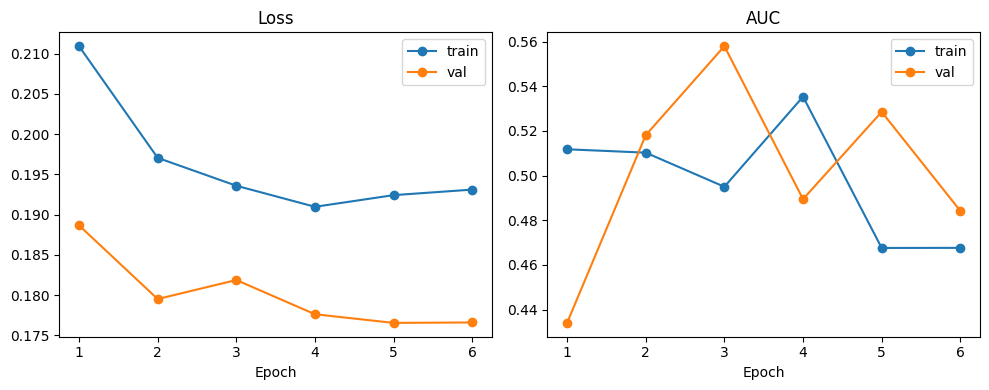

In [8]:
# Training curves help separate reconstruction learning from classification improvement.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_auc'], marker='o', label='train')
plt.plot(history_df['epoch'], history_df['val_auc'], marker='o', label='val')
plt.title('Macro OvR AUC')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()


Test loss: 0.1784
Test AUC : 0.498
Confusion matrix: [[937   0]
 [ 63   0]]
Loss components: {'recon_loss': 0.056636033668404535, 'kl_loss': 0.34062794418562026, 'cls_loss': 0.23631760679067126, 'consistency_loss': 0.0024136306592337196}


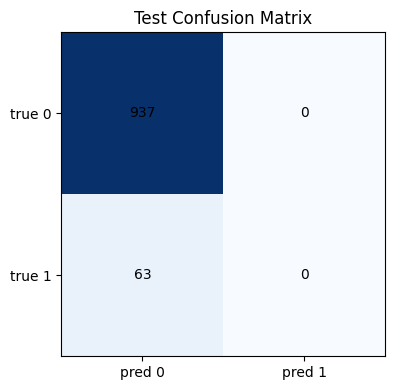

In [9]:
# Final held-out evaluation on patients the model never saw during training.
test_loss, test_auc, test_acc, test_bal_acc, test_probs, test_targets, test_logs = run_epoch(model, test_loader, optimizer=None)
test_pred = test_probs.argmax(axis=1)
cm = confusion_matrix(test_targets, test_pred, labels=list(range(5)))

print('Test loss        :', round(test_loss, 4))
print('Test macro OvR AUC:', round(float(test_auc), 4) if not np.isnan(test_auc) else 'nan')
print('Test accuracy    :', round(float(test_acc), 4))
print('Test balanced acc:', round(float(test_bal_acc), 4) if not np.isnan(test_bal_acc) else 'nan')
print('Loss components  :', test_logs)
print(classification_report(
    test_targets,
    test_pred,
    labels=list(range(5)),
    target_names=[PIRADS_CLASS_NAMES[i] for i in range(5)],
    zero_division=0,
))

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Test Confusion Matrix')
plt.xticks(range(5), [f'pred {i}' for i in range(1, 6)], rotation=45)
plt.yticks(range(5), [f'true {i}' for i in range(1, 6)])
for i in range(5):
    for j in range(5):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

checkpoint_metrics = {
    'test_loss': float(test_loss),
    'test_auc_macro_ovr': None if np.isnan(test_auc) else float(test_auc),
    'test_accuracy': float(test_acc),
    'test_balanced_accuracy': None if np.isnan(test_bal_acc) else float(test_bal_acc),
    'test_loss_components': test_logs,
}
checkpoint_payload = build_checkpoint_payload(
    model,
    metrics=checkpoint_metrics,
    class_weights=[float(x) for x in CLASS_WEIGHTS.detach().cpu().numpy()],
)
torch.save(checkpoint_payload, PROJECT_MODEL_PATH)
history_df.to_csv(PROJECT_MODEL_PATH.parent / 'training_history.csv', index=False)
print(f'Saved model checkpoint: {PROJECT_MODEL_PATH}')
print(f'Saved training history : {PROJECT_MODEL_PATH.parent / "training_history.csv"}')


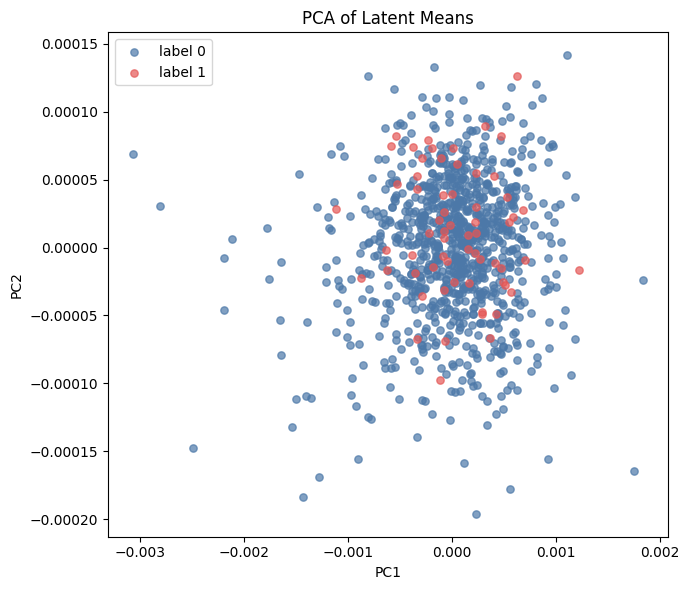

In [10]:
# Project the latent means to 2D to see whether the learned representation separates PI-RADS classes.
model.eval()
all_z, all_y = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        recon, mu, logvar, logits, z = model(x)
        all_z.append(mu.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy().ravel())

Z = np.concatenate(all_z)
Y = np.concatenate(all_y).astype(int)
coords = PCA(n_components=2, random_state=42).fit_transform(Z)

plt.figure(figsize=(7, 6))
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for label_idx, color in enumerate(colors):
    mask = Y == label_idx
    if mask.any():
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=28,
            alpha=0.7,
            label=PIRADS_CLASS_NAMES[label_idx],
            c=[color],
        )
plt.title('PCA of Latent Means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()



## 3. Project Architecture

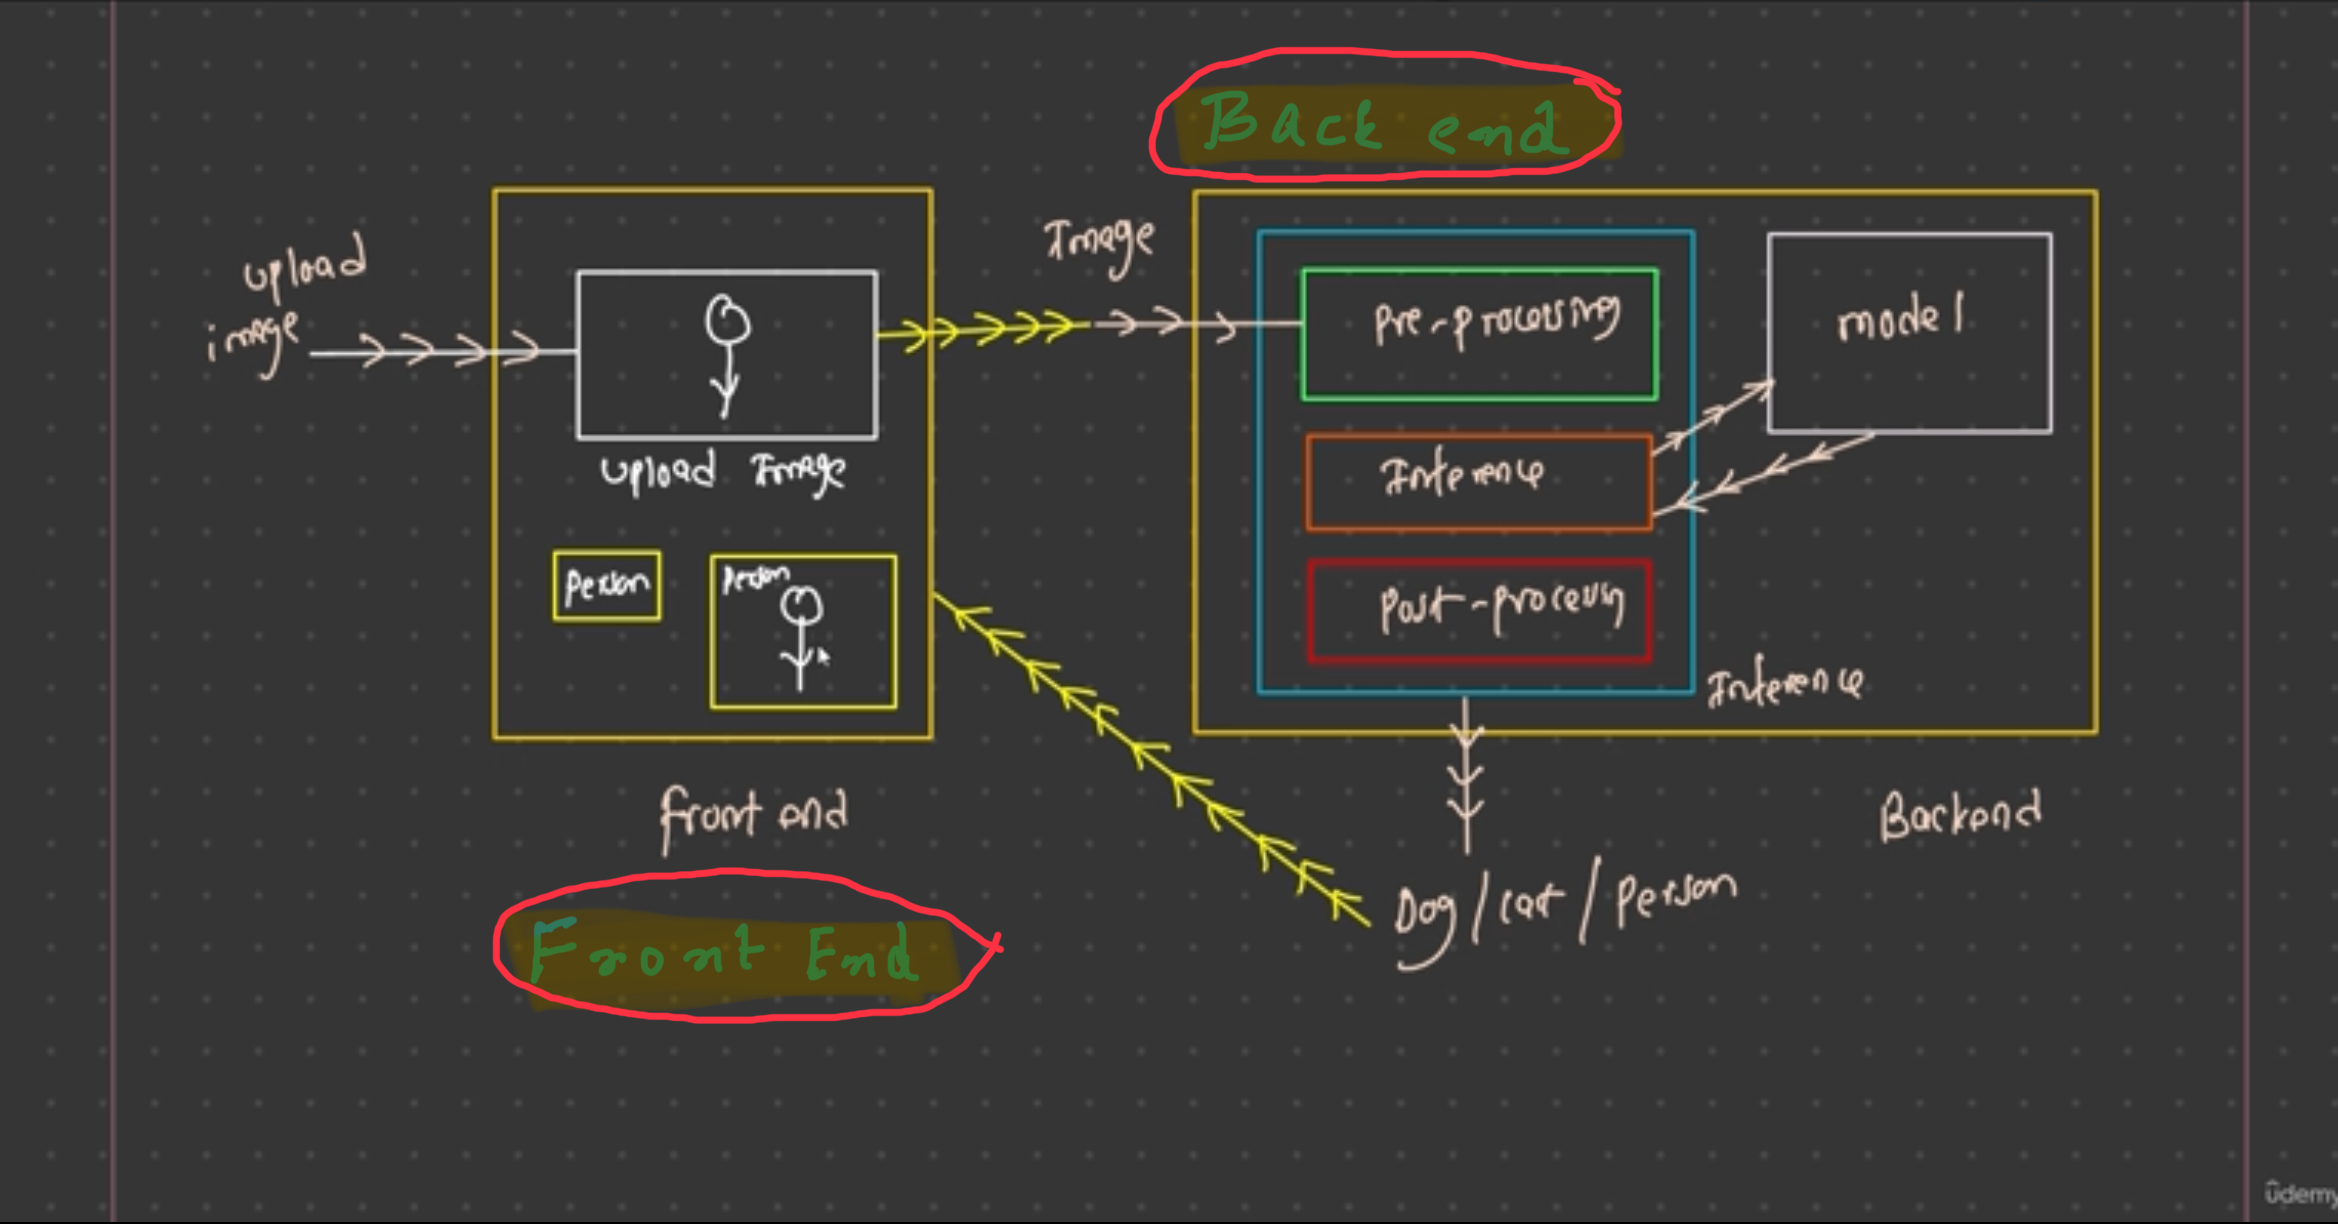
